In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
#reading the csv
df = pd.read_csv("classification_dataset.csv")

#Get the top rows to see a sample from dataset
df.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
1,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0
2,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,0
3,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,0
4,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,0


In [3]:
#Split features and target
x = df.drop(columns=['loan_approval_status'])
y = df['loan_approval_status']

In [4]:
#Split the features and targets into train and test

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
#Seperating the columns as numerical and categorical for scalng and encoding

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x_train.select_dtypes(include=['object']).columns

In [7]:
#Making a pipeline with both scaler and encoder and saving them as transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [8]:
#Applying the scaling and encodinng for train and test rows
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [9]:
#Modelling Logistic Regression with max_iter = 1000 to shape the gradient descent
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

Logistic Regression


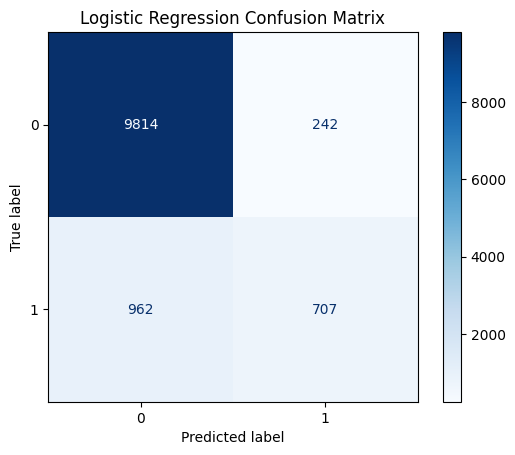

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10056
           1       0.74      0.42      0.54      1669

    accuracy                           0.90     11725
   macro avg       0.83      0.70      0.74     11725
weighted avg       0.89      0.90      0.88     11725



In [14]:
print("Logistic Regression")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred_lr))